# 꽃분류 프로젝트 실험

이미지는 tensorflow 제공 꽃이미지
설명은 readme에 적어두겠습니다

resize는 160x160으로 진행

VGG16 모델 전이학습진행
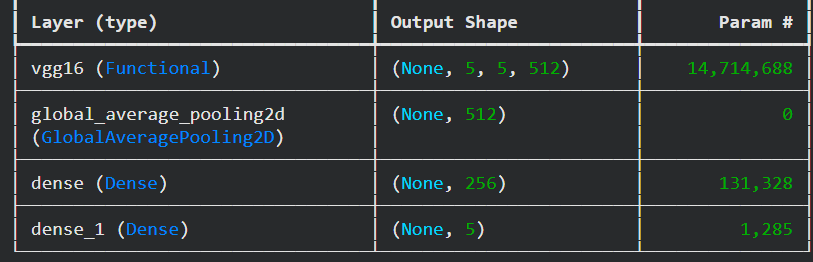

# 최종 정확도는 78.125

In [1]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
(raw_train, raw_validation, raw_test), metadata = tfds.load(
    name='tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    download=True,
    with_info=True,
    as_supervised=True,
)

2026-03-11 16:15:49.573309: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-11 16:15:49.573327: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-11 16:15:49.573332: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 13.50 GB
2026-03-11 16:15:49.573345: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-11 16:15:49.573354: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [3]:
IMG_SIZE = 160 # 리사이징할 이미지의 크기

# VGG 전처리 함수 import
from tensorflow.keras.applications.vgg16 import preprocess_input


def format_example(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # VGG 전용 전처리 사용  (GPT의 추천)
    image = preprocess_input(image)

    return image, label

train = raw_train.map(format_example)
validation = raw_validation.map(format_example)
test = raw_test.map(format_example)

In [4]:
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 1000

train_batches = train.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
validation_batches = validation.batch(BATCH_SIZE)
test_batches = test.batch(BATCH_SIZE)

In [5]:
IMG_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

# Create the base model from the pre-trained model VGG16
base_model = tf.keras.applications.VGG16(input_shape=IMG_SHAPE,
                                         include_top=False,
                                         weights='imagenet')

In [6]:
for image_batch, label_batch in train_batches.take(1):
    break

image_batch.shape, label_batch.shape

2026-03-11 16:15:50.117214: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


(TensorShape([32, 160, 160, 3]), TensorShape([32]))

In [7]:
feature_batch = base_model(image_batch)
feature_batch.shape

TensorShape([32, 5, 5, 512])

In [8]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

In [9]:
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 512)


In [10]:

dense_layer = tf.keras.layers.Dense(units=256,
                                    activation='relu')

# 이부분에서 5개로 바꿔준다 : label의 class가 5개이기때문
prediction_layer = tf.keras.layers.Dense(units=5,
                                         activation='softmax')

prediction_batch = prediction_layer(dense_layer(feature_batch_average))
print(prediction_batch.shape)

(32, 5)


In [11]:
base_model.trainable = False

In [12]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    
    # Dropout 추가
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(5, activation='softmax')
])

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [14]:
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [15]:
validation_steps=20
loss0, accuracy0 = model.evaluate(validation_batches, steps = validation_steps)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

2026-03-11 16:15:50.438006: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1635 - loss: 13.4784
initial loss: 13.48
initial accuracy: 0.16


In [16]:
EPOCHS = 20   # 이번에는 이전보다 훨씬 빠르게 수렴되므로 5Epoch이면 충분합니다.

# EarlyStopping 추가
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Checkpoint 추가, 베스트 모델만 저장하기 위함
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# val_loss가 개선되지 않으면 learning rate 조절
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stopping,checkpoint,reduce_lr,]

# fit
history = model.fit(
    train_batches,
    epochs=EPOCHS,
    validation_data=validation_batches,
    callbacks=callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3047 - loss: 8.6179
Epoch 1: val_accuracy improved from None to 0.59946, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3869 - loss: 6.7099 - val_accuracy: 0.5995 - val_loss: 2.4421 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5691 - loss: 3.8302
Epoch 2: val_accuracy improved from 0.59946 to 0.73025, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.5814 - loss: 3.5922 - val_accuracy: 0.7302 - val_loss: 1.6277 - learning_rate: 1.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.6518 - loss: 2.9005
Epoch 3: val_accuracy improved from 0.73025 to 0.75477, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/st

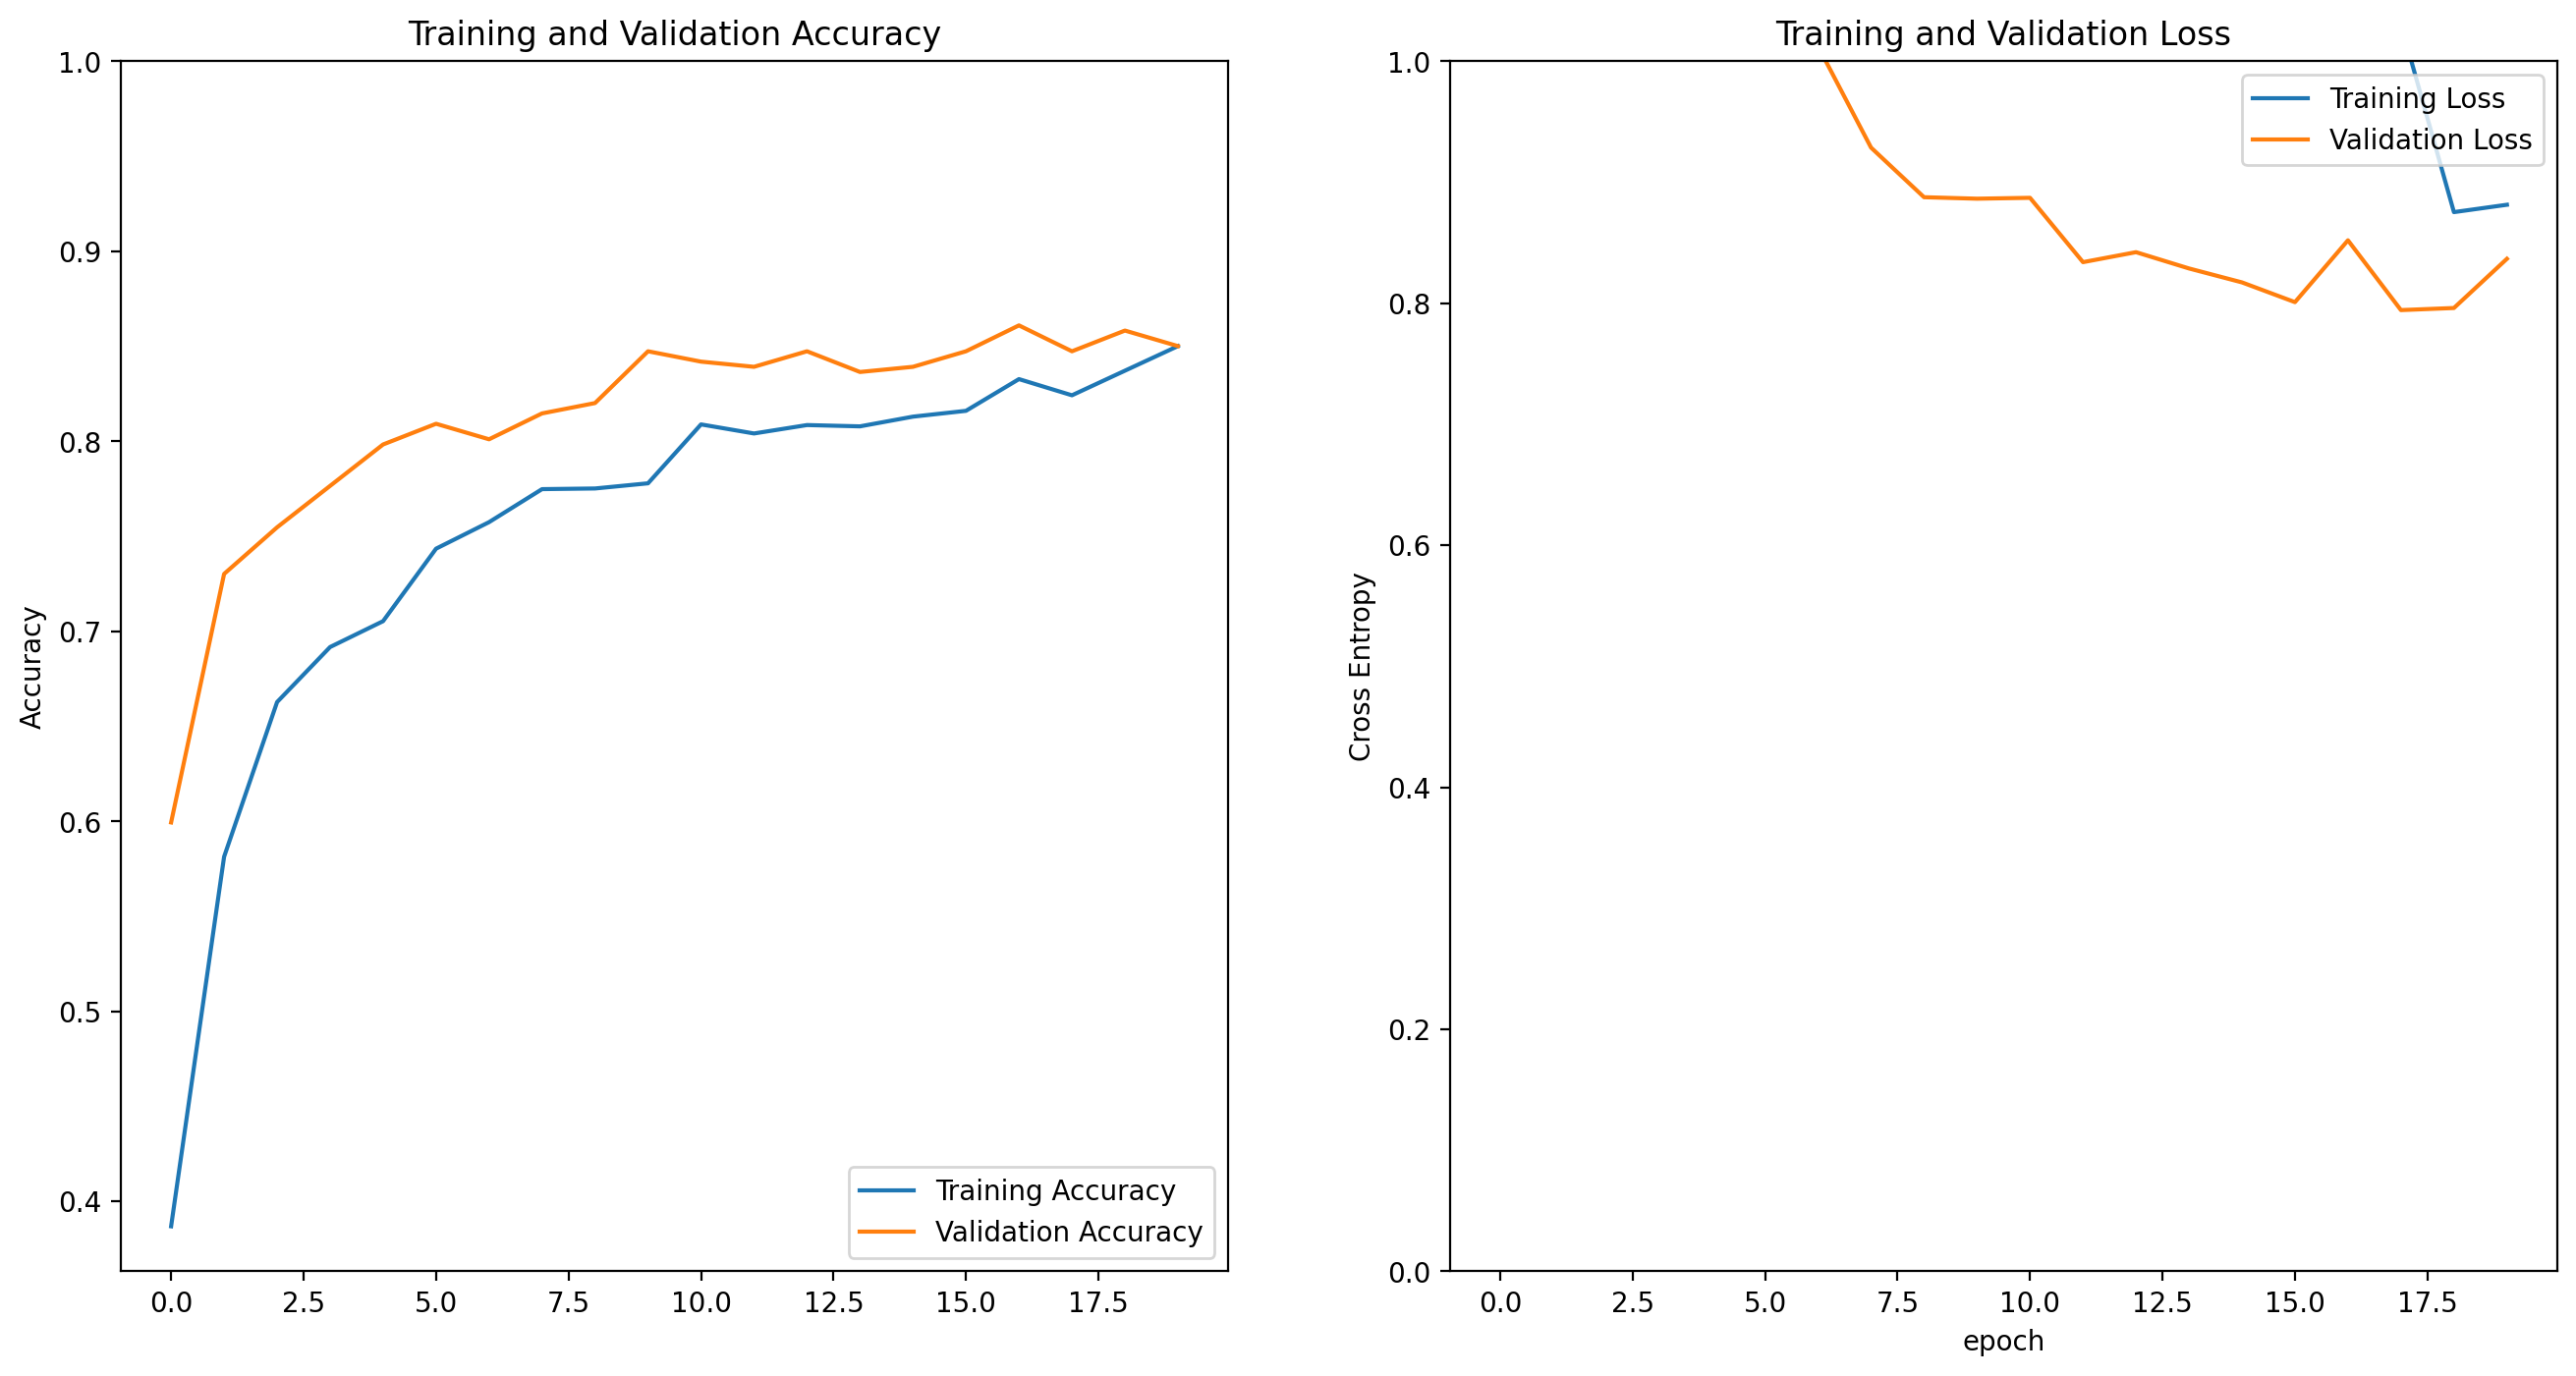

In [17]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [18]:
for image_batch, label_batch in test_batches.take(1):
    images = image_batch
    labels = label_batch
    predictions = model.predict(image_batch)
    pass

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


2026-03-11 16:18:44.493759: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-03-11 16:18:44.664016: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


array([[1.0732246e-14, 2.0540190e-09, 1.0000000e+00, 4.4614932e-15,
        4.7954739e-08],
       [1.0000000e+00, 1.8724998e-21, 3.6004415e-28, 1.9586539e-28,
        1.1911290e-27],
       [9.6326426e-02, 1.4568953e-09, 1.4210194e-04, 9.0353149e-01,
        3.1113393e-12],
       [2.4618061e-09, 2.6979436e-09, 8.3984029e-01, 5.0073915e-13,
        1.6015966e-01],
       [9.9895215e-01, 7.7398261e-04, 2.2672100e-09, 2.6798437e-04,
        5.7976213e-06],
       [1.0000000e+00, 1.0263651e-12, 1.4180088e-17, 2.0984564e-14,
        3.2451857e-17],
       [4.0957597e-03, 7.8689067e-07, 9.9534851e-01, 5.5375503e-04,
        1.1961791e-06],
       [1.1997409e-03, 9.9855441e-01, 4.4747150e-15, 2.4579820e-04,
        1.1987541e-12],
       [4.1890214e-10, 2.2827910e-20, 6.2267212e-11, 1.0000000e+00,
        5.9828209e-20],
       [1.0000000e+00, 1.1728421e-18, 1.4290951e-28, 2.2605066e-17,
        8.4570088e-28],
       [1.0000000e+00, 1.1860179e-14, 8.5199920e-20, 1.2025037e-16,
        8.78

In [19]:
import numpy as np
predictions = np.argmax(predictions, axis=1)
predictions

array([2, 0, 3, 2, 0, 0, 2, 1, 3, 0, 0, 0, 3, 4, 0, 3, 2, 0, 2, 4, 2, 0,
       2, 0, 1, 3, 1, 2, 4, 0, 0, 4])

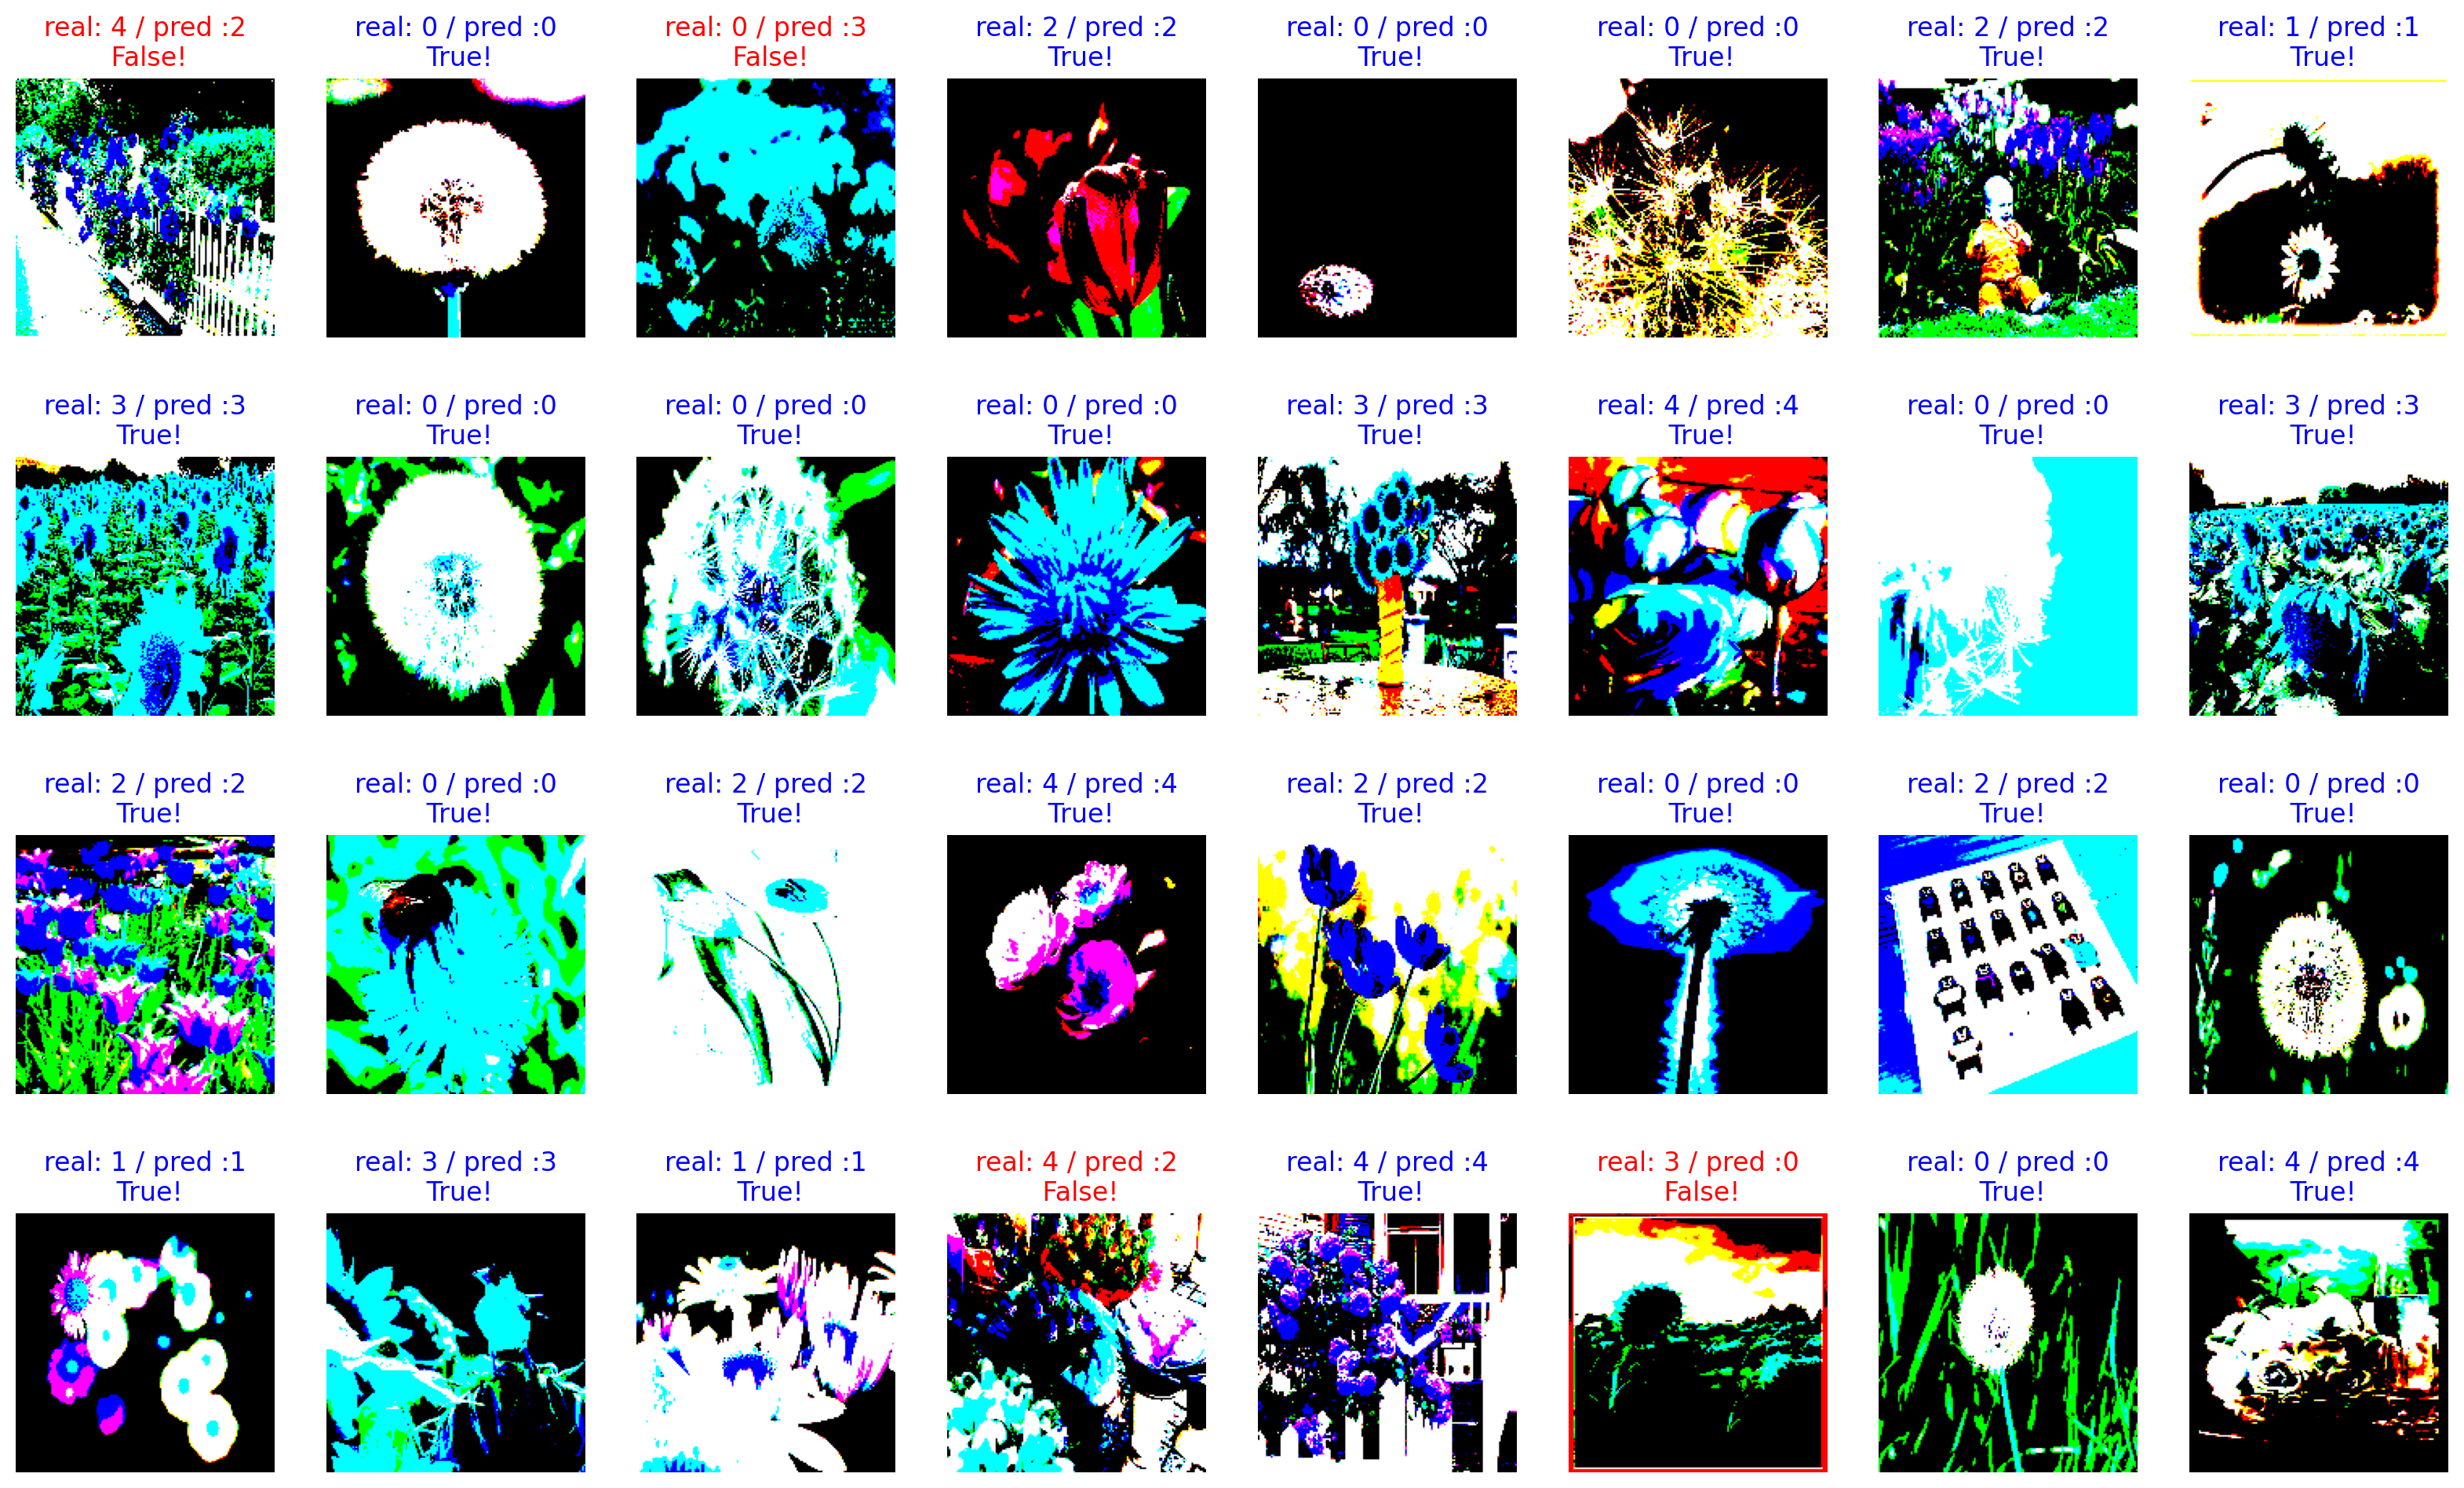

In [20]:
plt.figure(figsize=(20, 12))

for idx, (image, label, prediction) in enumerate(zip(images, labels, predictions)):
    plt.subplot(4, 8, idx+1)
    image = (image + 1) / 2
    plt.imshow(image)
    correct = label == prediction
    title = f'real: {label} / pred :{prediction}\n {correct}!'
    if not correct:
        plt.title(title, fontdict={'color': 'red'})
    else:
        plt.title(title, fontdict={'color': 'blue'})
    plt.axis('off')

In [21]:
count = 0
for image, label, prediction in zip(images, labels, predictions):
    correct = label == prediction
    if correct:
        count = count + 1

print(count / 32 * 100)

87.5
